# 📊 **Student Performance Dataset Overview**

## 📌 **Project Objective

The primary goal of this project is to apply advanced Data Mining techniques to a student performance dataset to uncover hidden patterns and predict academic outcomes. By utilizing both supervised and unsupervised learning, this analysis aims to segment the student population into behavioral groups and build a reliable model to predict final letter grades based on academic and lifestyle factors.


## 📌 **Dataset Description**  
This dataset contains student academic records to analyze performance trends, study habits, and influencing factors.  

---

## 🗂️ **Feature Summary**  

| Feature Name               | Description |
|---------------------------|-------------|
| 🎓 **Student_ID**         | Unique identifier for each student |
| 👤 **First_Name** / **Last_Name** | Student's first and last name |
| ✉️ **Email**              | Contact email (can be anonymized) |
| ⚧ **Gender**             | Male, Female, Other |
| 🔢 **Age**               | Age of the student |
| 🏫 **Department**        | Student's academic department (CS, Engineering, Business, etc.) |
| 📈 **Attendance (%)**    | Attendance percentage (0-100%) |
| 📝 **Midterm_Score**     | Midterm exam score (out of 100) |
| 🎓 **Final_Score**       | Final exam score (out of 100) |
| 📚 **Assignments_Avg**   | Average assignment scores (out of 100) |
| 📊 **Quizzes_Avg**       | Average quiz scores (out of 100) |
| 💬 **Participation_Score** | Class participation score (0-10) |
| 🏆 **Projects_Score**    | Project evaluation score (out of 100) |
| 🏅 **Total_Score**       | Weighted sum of all academic scores |
| 🔤 **Grade**             | Letter grade (A, B, C, D, F) |
| ⏳ **Study_Hours_per_Week** | Average weekly study hours |
| 🎭 **Extracurricular_Activities** | Whether the student participates in extracurriculars (Yes/No) |
| 🌍 **Internet_Access_at_Home** | Availability of home internet access (Yes/No) |
| 🎓 **Parent_Education_Level** | Highest education level of parents (None, High School, Bachelor's, Master's, PhD) |
| 💰 **Family_Income_Level** | Family income category (Low, Medium, High) |
| 😰 **Stress_Level (1-10)** | Self-reported stress level (1: Low, 10: High) |
| 🌙 **Sleep_Hours_per_Night** | Average hours of sleep per night |

---


## 📌 Data Mining Methodologies Applied

In accordance with the project requirements, the following core Data Mining phases were implemented:

Data Reduction: * Attribute Subset Selection: We manually removed non-predictive attributes (e.g., Student_ID, Names, Email) to reduce dimensionality and improve model efficiency.

Histogram Analysis: Used to discretize continuous variables (Total Scores) into frequency distributions for better pattern recognition.

Cluster Analysis (Unsupervised Learning):

K-Means Clustering: Applied to group students into "High," "Medium," and "Low" performing segments based on the relationship between Study Hours and Total Scores. This reveals how student behavior directly impacts results without using pre-defined labels.

Classification (Supervised Learning):

Random Forest Classifier: A robust machine learning model used to predict the categorical Grade (A, B, C, D, F). This model identifies which features (like Attendance or Stress Levels) are the strongest predictors of a student's final grade.


## 🗂️ Expected Insights

By the end of this notebook, we will demonstrate:

How accurately we can predict a student's grade using only their mid-semester data.

The visualization of distinct student clusters based on effort versus outcome.

A ranked list of the most influential factors contributing to student success.


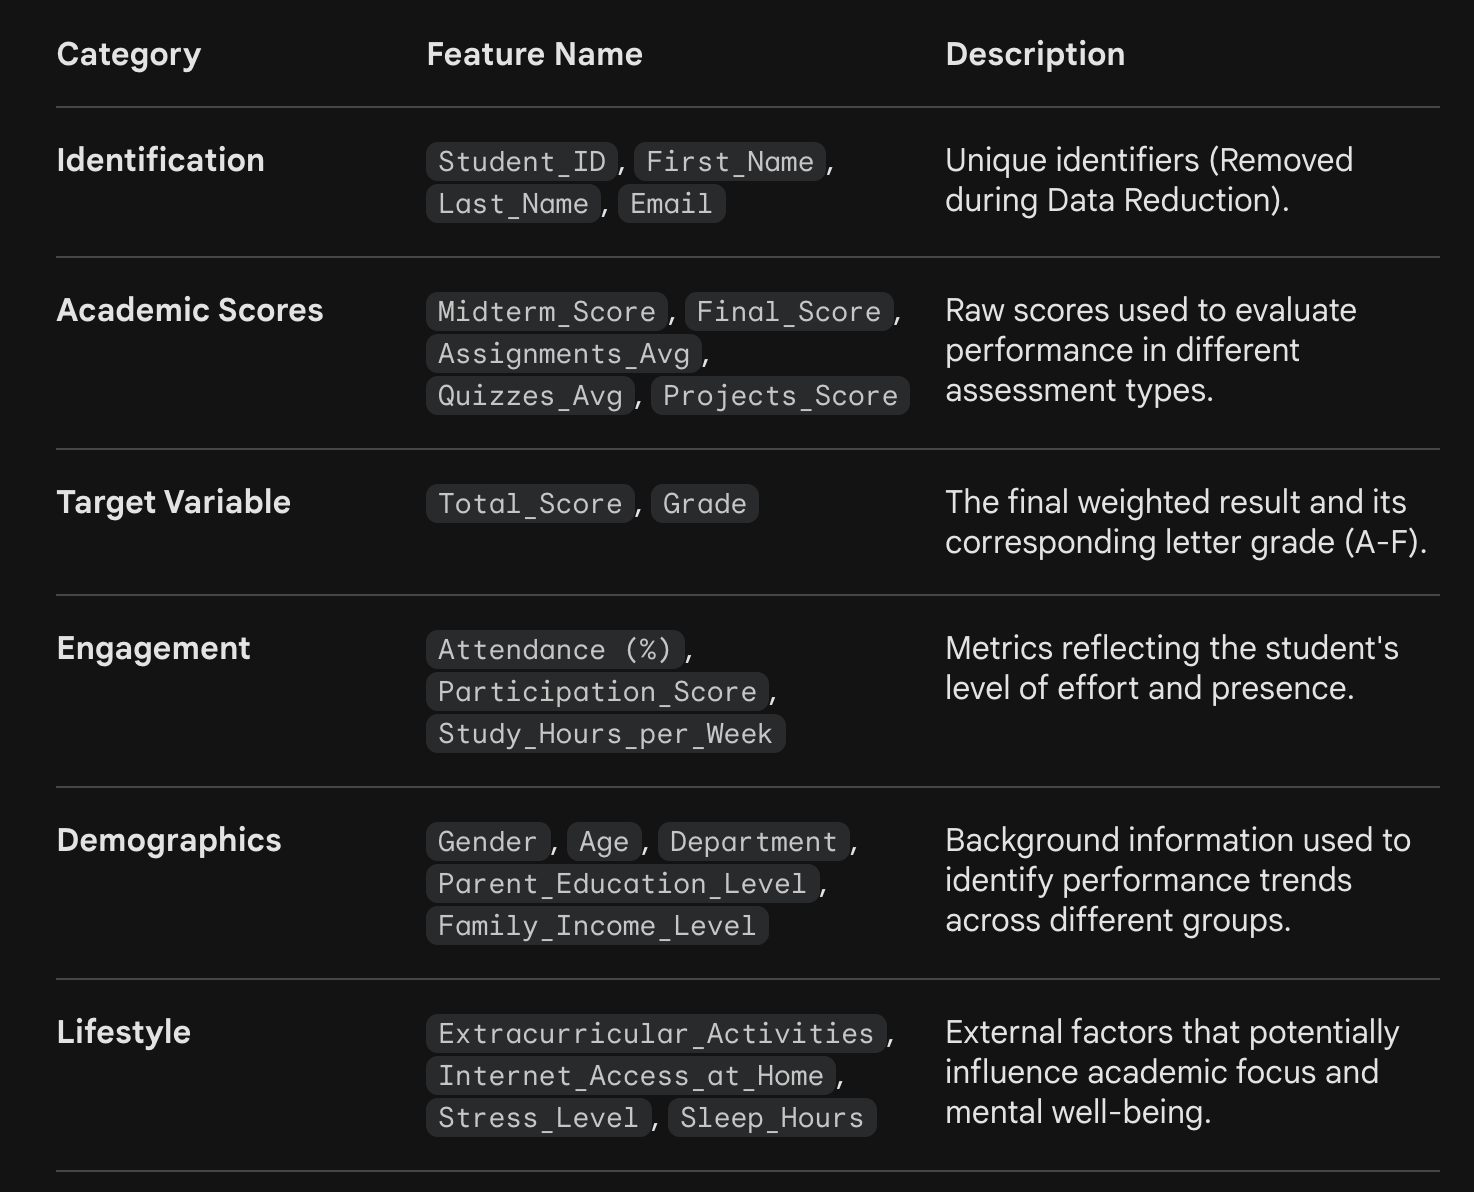

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students Performance Dataset.json
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/metadata.xlsx
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students_Grading_Dataset_Biased.csv
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students Performance Dataset.csv
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students_Grading_Dataset_Biased.json


In [2]:
# ==========================================
# 1. IMPORT LIBRARIES AND LOAD DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Load the primary dataset
df = pd.read_csv('/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students Performance Dataset.csv')

# Display the first few rows to understand the structure
print("Dataset Preview:")
display(df.head())


Dataset Preview:


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


In [4]:
# ==========================================
# 2. DATA PREPROCESSING & CLEANING
# ==========================================
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                   0
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                  0
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1025
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64


In [5]:
# Basic info about columns and types
print("\nDataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score    

In [6]:
# Dropping unnecessary identifiers for analysis
df_clean = df.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email'])


In [7]:
# Convert categorical variables to numeric (Encoding)
# This allows the model to process Gender, Department, and Parent Education
df_encoded = pd.get_dummies(df_clean, drop_first=True)


In [8]:
# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Statistical summary
print("\nStatistical Summary:")
display(df_clean.describe())


Statistical Summary:


,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,21.048400,75.356076,70.701924,69.546552,74.956320,74.836214,49.963720,74.78305,71.652097,17.521140,5.507200,6.514420
std,1.989786,14.392716,17.436325,17.108996,14.404287,14.423848,28.989785,14.54243,7.230097,7.193035,2.886662,1.446155
min,18.000000,50.010000,40.000000,40.010000,50.000000,50.000000,0.000000,50.00000,50.602000,5.000000,1.000000,4.000000
25%,19.000000,62.945000,55.707500,54.697500,62.340000,62.357500,25.075000,61.97000,66.533875,11.500000,3.000000,5.300000
50%,21.000000,75.670000,70.860000,69.485000,75.090000,74.905000,49.600000,74.54000,71.696250,17.400000,6.000000,6.500000
75%,23.000000,87.862500,85.760000,83.922500,87.352500,87.292500,75.500000,87.63000,76.711625,23.700000,8.000000,7.800000
max,24.000000,100.000000,99.990000,99.980000,99.990000,99.990000,100.000000,100.00000,95.091500,30.000000,10.000000,9.000000


/tmp/ipykernel_17/1125175516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Grade', palette='viridis', order=['A', 'B', 'C', 'D', 'F'])


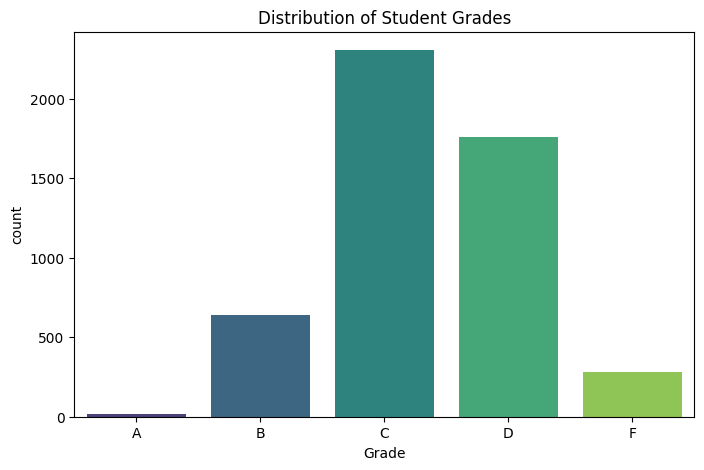

In [9]:
# A. Distribution of Grades
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Grade', palette='viridis', order=['A', 'B', 'C', 'D', 'F'])
plt.title('Distribution of Student Grades')
plt.show()


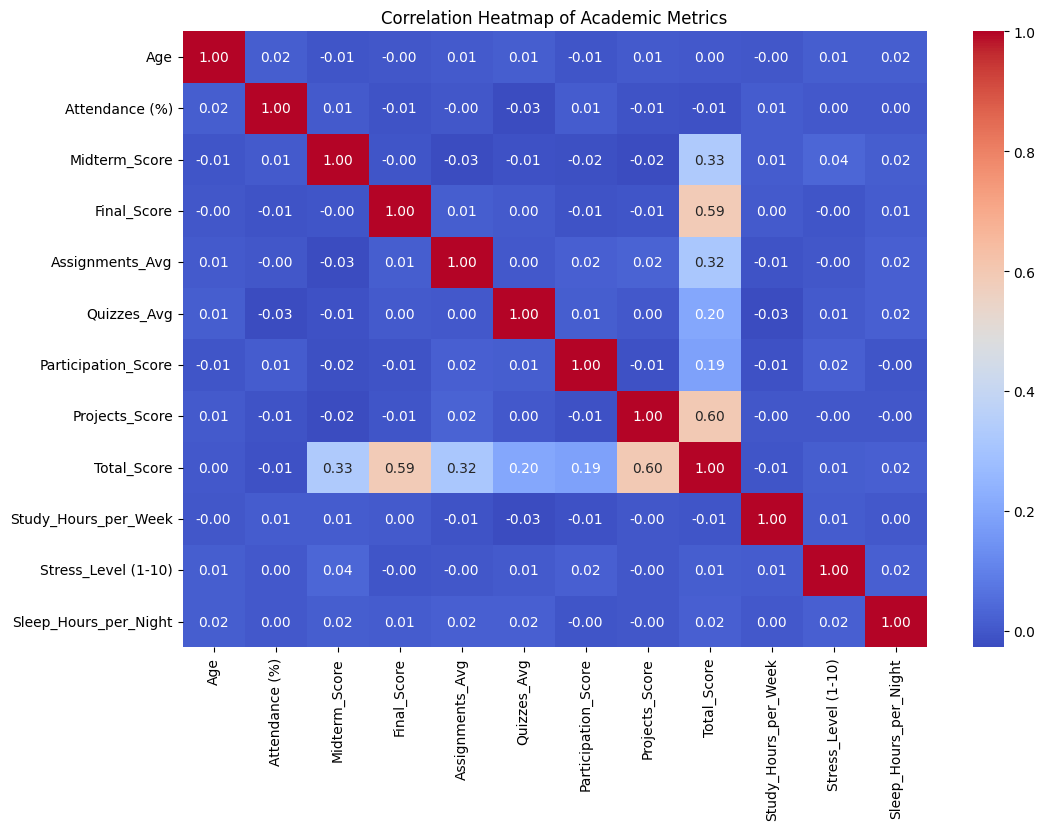

In [10]:
# B. Correlation Heatmap
# Visualizing how different scores relate to the Total Score
plt.figure(figsize=(12, 8))
correlation_matrix = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Academic Metrics')
plt.show()

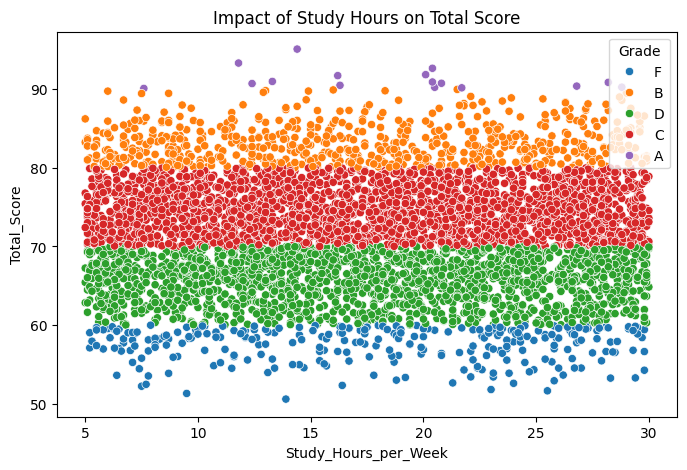

In [11]:
# C. Study Hours vs. Total Score
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Study_Hours_per_Week', y='Total_Score', hue='Grade')
plt.title('Impact of Study Hours on Total Score')
plt.show()


Original columns: 23
Reduced columns: 19


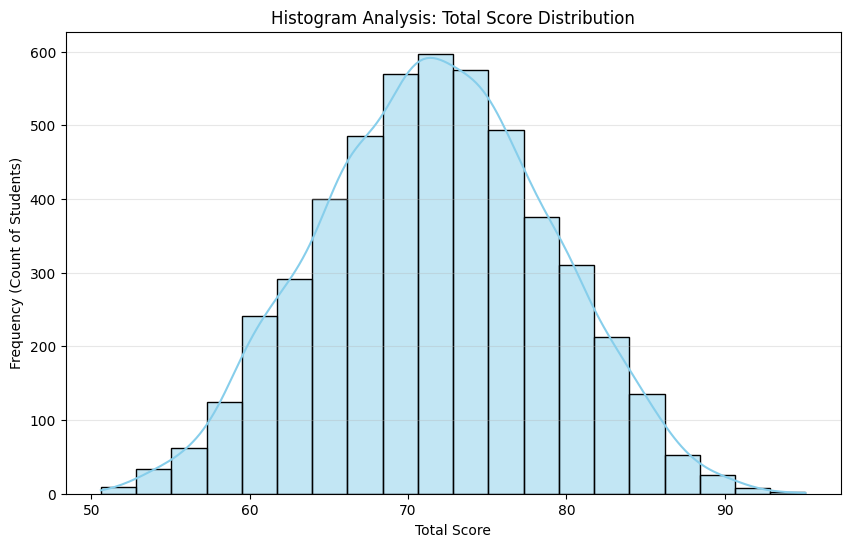

In [12]:
drop_columns = ['Student_ID', 'First_Name', 'Last_Name', 'Email']
df_reduced = df.drop(columns=drop_columns)

print(f"Original columns: {df.shape[1]}")
print(f"Reduced columns: {df_reduced.shape[1]}")

# ==========================================
# 3. DATA REDUCTION TECHNIQUE B: Histogram Analysis
# ==========================================
# Histogram Analysis reduces the data by binning. Instead of looking at 
# 5,000 individual 'Total_Score' values, we group them into frequency bins.
plt.figure(figsize=(10, 6))
sns.histplot(df_reduced['Total_Score'], bins=20, kde=True, color='skyblue')
plt.title('Histogram Analysis: Total Score Distribution')
plt.xlabel('Total Score')
plt.ylabel('Frequency (Count of Students)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
# ==========================================
# 4. PREDICTIVE MODELING (Linear Regression)
# ==========================================
# Define Features (X) and Target (y)
# We want to predict 'Total_Score' based on other factors
X = df_encoded.drop('Total_Score', axis=1)

In [14]:
# Dropping 'Grade' from X as it is directly derived from Total_Score
X = X.drop(columns=[col for col in X.columns if 'Grade' in col])
y = df_encoded['Total_Score']


In [15]:
# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Initialize and Train Model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [17]:
# Make Predictions
y_pred = model.predict(X_test)

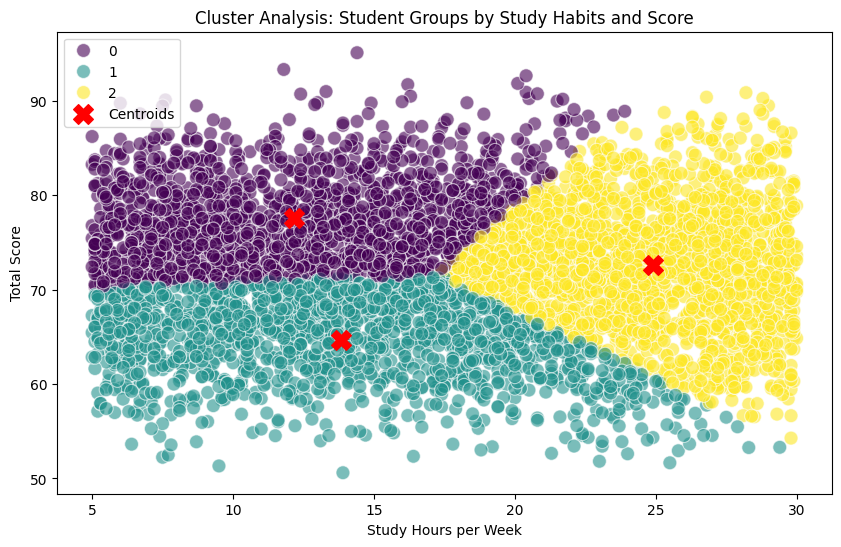

Cluster Characteristics (Mean Values):
         Study_Hours_per_Week  Total_Score
Cluster                                   
0                   12.168533    77.544993
1                   13.871668    64.630106
2                   24.909192    72.575284


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load Data
file_path = '/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students Performance Dataset.csv'
df = pd.read_csv(file_path)

# 2. Select Features for Clustering
# We'll group students based on Study Hours and Total Score to find patterns
features = ['Study_Hours_per_Week', 'Total_Score']
X = df[features]

# 3. Data Scaling (Required for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply K-Means Clustering
# Let's group them into 3 clusters: High, Medium, and Low achievers
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Study_Hours_per_Week', y='Total_Score', 
                hue='Cluster', palette='viridis', s=100, alpha=0.6)

# Plot the Centroids (The "center" of each cluster)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title('Cluster Analysis: Student Groups by Study Habits and Score')
plt.xlabel('Study Hours per Week')
plt.ylabel('Total Score')
plt.legend()
plt.show()

# 6. Description of Clusters
print("Cluster Characteristics (Mean Values):")
print(df.groupby('Cluster')[features].mean())

In [19]:
# ==========================================
# 5. MODEL EVALUATION
# ==========================================
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")


Model Performance:
Mean Squared Error: 0.00
R-squared Score: 1.00


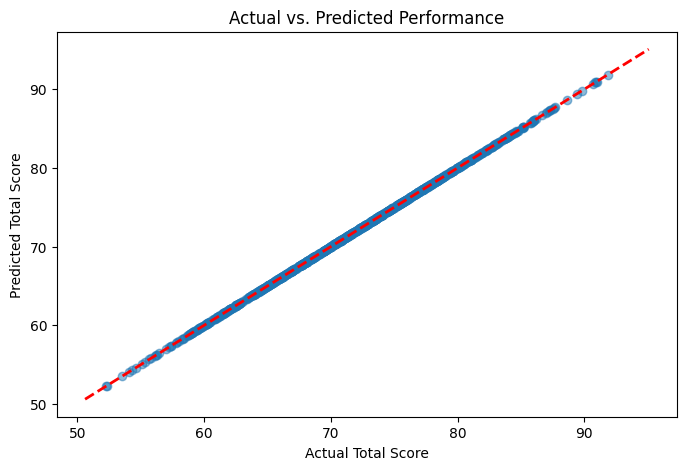

In [20]:
# Visualize Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Total Score')
plt.ylabel('Predicted Total Score')
plt.title('Actual vs. Predicted Performance')
plt.show()


In [21]:
# ==========================================
# 6. EXPORTING RESULTS
# ==========================================
# Save the cleaned and encoded data to an Excel file for further use
df_clean.to_excel('Cleaned_Student_Data.xlsx', index=False)
print("\nCleaned data has been exported to 'Cleaned_Student_Data.xlsx'.")


Cleaned data has been exported to 'Cleaned_Student_Data.xlsx'.
